In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import pandas as pd
import pytz
from timezonefinder import TimezoneFinder
from datetime import datetime

# open hourly ERA5

In [3]:
ds = xr.open_dataset('/Users/gahe5417/data/ERA5/hourly_air.2m.era5.CONUS.January.2001.nc')
ds = ds.sel(time=slice('2001-01-01 08:00:00', '2001-01-31 15:59:59'))

# Define arrays

In [4]:
local_time = xr.zeros_like(ds['air'])
time_zone = xr.zeros_like(ds['air'].mean('time')).astype('str')
tavg = xr.zeros_like(ds['air'])
tmax = xr.zeros_like(ds['air'].groupby(ds.time.dt.day).mean())
tmin = xr.zeros_like(ds['air'].groupby(ds.time.dt.day).mean())

# Define local time

In [5]:
# 1. Initialize the finder
tf = TimezoneFinder()
time_index = ds["time"].to_index()

In [6]:
for j in range(len(ds["lat"])):
    for i in range(len(ds["lon"])):
      # 2. Provide your coordinates (e.g., Times Square, NY)
      lat, lon = ds["lat"].values[j], ds["lon"].values[i]

      # 3. Get the Timezone ID (e.g., 'America/New_York')
      tz_string = tf.timezone_at(lng=lon-360, lat=lat)

      # 4. Use pytz to create a timezone-aware datetime object
      local_tz = pytz.timezone(tz_string)
      time_zone.loc[{'lat':lat,'lon':lon}] = time_index[0].tz_localize("UTC").tz_convert(local_tz).strftime('%z')
      local_time.loc[{'lat':lat,'lon':lon}] = time_index.tz_localize("UTC").tz_convert(local_tz).to_pydatetime().astype('datetime64[ns]')

/var/folders/41/jpdddhvx1_bfhbywzg083cy00000gt/T/ipykernel_71072/2941669516.py:12: UserWarning: no explicit representation of timezones available for np.datetime64
  local_time.loc[{'lat':lat,'lon':lon}] = time_index.tz_localize("UTC").tz_convert(local_tz).to_pydatetime().astype('datetime64[ns]')


# Assign new time as coordinate

In [7]:
local_time = local_time.rename('local_time').astype('datetime64[ns]') 
ds = ds.assign_coords(local_time=local_time)
ds = ds.assign_coords(time_zone=time_zone)

# Create Mask

In [8]:
mask_tz = xr.zeros_like(time_zone).astype(int)
kn = len(np.unique(time_zone.values))
for tz in np.arange(1,kn+1):
    tz_name = np.unique(time_zone.values)[tz-1]
    mask_tz = xr.where(time_zone == tz_name, tz, mask_tz)

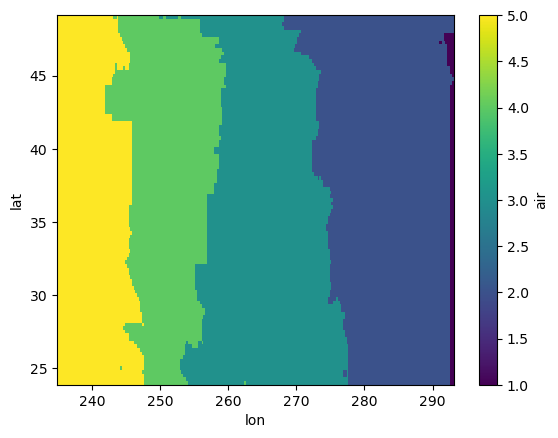

In [9]:
mask_tz.plot()

# Compute Tmin and Tmax by grouping on local time

In [10]:
np.unique(time_zone.values)

array(['-0400', '-0500', '-0600', '-0700', '-0800'], dtype='<U32')

In [12]:

for tz in np.unique(time_zone.values):
  idy,idx = np.where(time_zone == tz)
  ilat = ds['lat'].isel(lat=idy)
  ilon = ds['lon'].isel(lon=idx)
  air_tz = ds['air'].where(time_zone == tz)
  local_day = air_tz.local_time.dt.day.mean({ 'lon','lat'})

  tmin.loc[{'lon':ilon,'lat':ilat}] = air_tz.groupby(local_day).min("time").sel(lon=ilon,lat=ilat)
  tmax.loc[{'lon':ilon,'lat':ilat}] = air_tz.groupby(local_day).max("time").sel(lon=ilon,lat=ilat)